# Домашнее задание 3: Визуализация данных Titanic

**Автор:** Кияткина Софья Павловна  
**Дата:** 13 марта 2026

В данной работе выполнена визуализация данных о пассажирах Титаника с использованием matplotlib, seaborn и plotly.

## 1. Импорт библиотек и загрузка данных

In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')

# Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# Загрузка данных
data = pd.read_csv('train.csv')

# Первые строки
print('Первые строки датасета:')
display(data.head())

print('\nИнформация о датасете:')
data.info()

print('\nОсновная статистика:')
display(data.describe())

Первые строки датасета:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Основная статистика:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Датасет содержит 891 запись о пассажирах. Основные признаки:
- `Survived` — факт выживания (0 = погиб, 1 = выжил)
- `Pclass` — класс билета (1, 2, 3)
- `Age` — возраст
- `Sex` — пол
- `Parch` — количество родителей/детей на борту

## 2. Визуализация распределений признаков

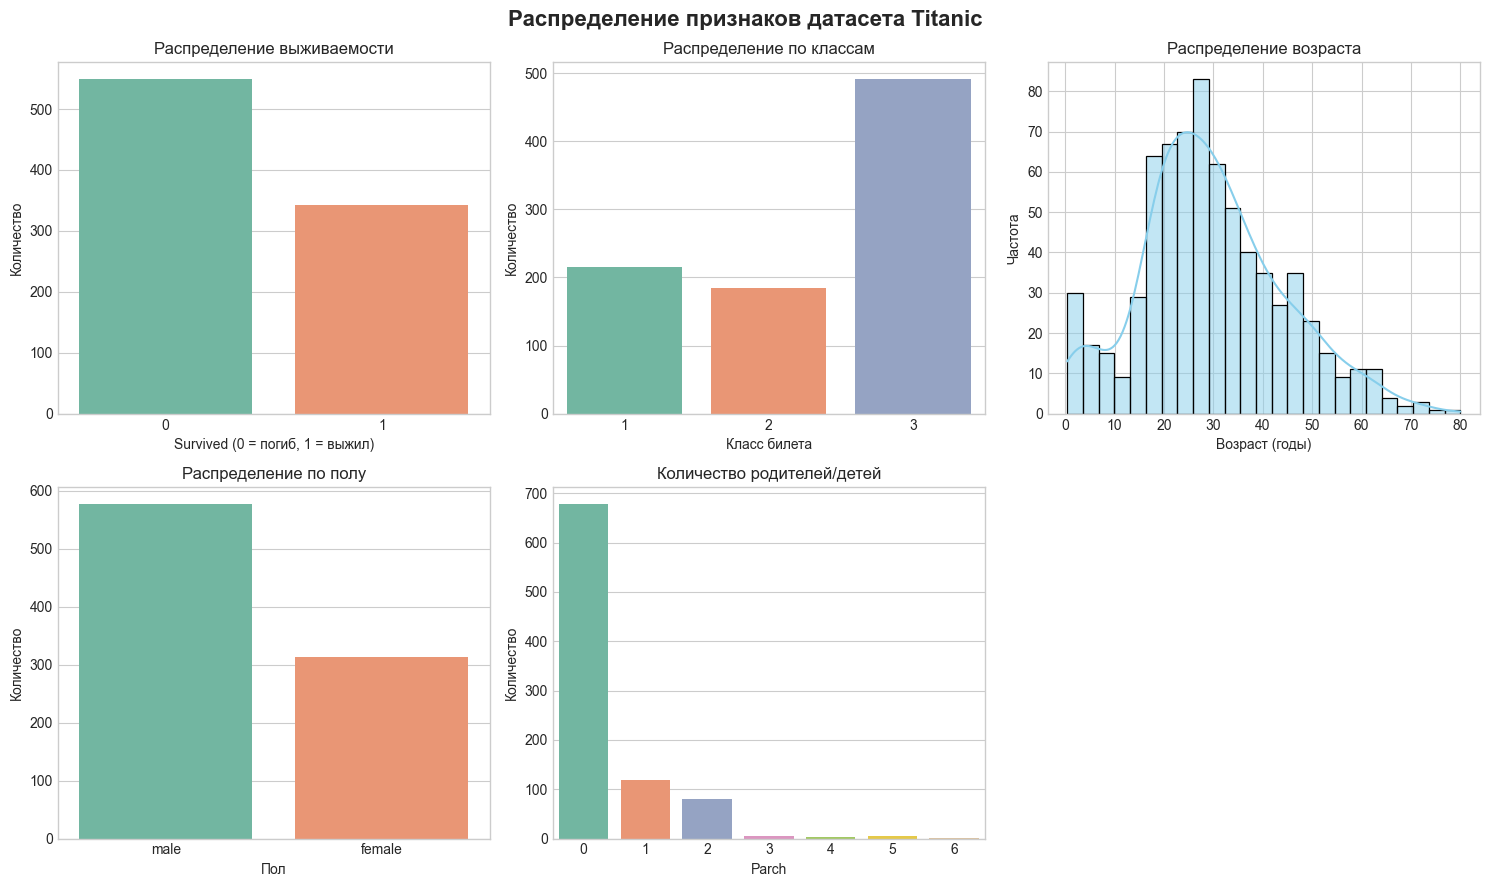

In [2]:
# Создание сетки графиков 2x3
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Распределение признаков датасета Titanic', fontsize=16, fontweight='bold')

# Survived
sns.countplot(data=data, x='Survived', ax=axes[0, 0], hue='Survived', palette='Set2', legend=False)
axes[0, 0].set_title('Распределение выживаемости')
axes[0, 0].set_xlabel('Survived (0 = погиб, 1 = выжил)')
axes[0, 0].set_ylabel('Количество')

# Pclass
sns.countplot(data=data, x='Pclass', ax=axes[0, 1], hue='Pclass', palette='Set2', legend=False)
axes[0, 1].set_title('Распределение по классам')
axes[0, 1].set_xlabel('Класс билета')
axes[0, 1].set_ylabel('Количество')

# Age
sns.histplot(data['Age'].dropna(), bins=25, kde=True, ax=axes[0, 2], color='skyblue')
axes[0, 2].set_title('Распределение возраста')
axes[0, 2].set_xlabel('Возраст (годы)')
axes[0, 2].set_ylabel('Частота')

# Sex
sns.countplot(data=data, x='Sex', ax=axes[1, 0], hue='Sex', palette='Set2', legend=False)
axes[1, 0].set_title('Распределение по полу')
axes[1, 0].set_xlabel('Пол')
axes[1, 0].set_ylabel('Количество')

# Parch
sns.countplot(data=data, x='Parch', ax=axes[1, 1], hue='Parch', palette='Set2', legend=False)
axes[1, 1].set_title('Количество родителей/детей')
axes[1, 1].set_xlabel('Parch')
axes[1, 1].set_ylabel('Количество')

# Убираем пустую ячейку
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

**Выводы по распределениям:**

1. **Survived**: Около 62% пассажиров погибли, только 38% выжили.
2. **Pclass**: Третий класс был самым многочисленным (~55% пассажиров).
3. **Age**: Возраст имеет распределение с пиком в районе 20-30 лет. Есть пропуски (177 значений).
4. **Sex**: Мужчин было значительно больше (~65%) по сравнению с женщинами (~35%).
5. **Parch**: Большинство пассажиров (~76%) путешествовали без родителей или детей.

## 3. Boxplot для возраста

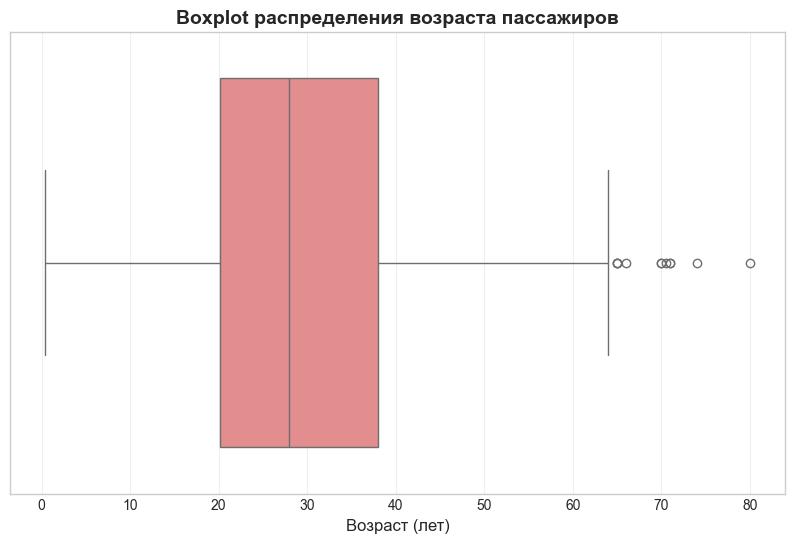

In [3]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='Age', color='lightcoral')
plt.title('Boxplot распределения возраста пассажиров', fontsize=14, fontweight='bold')
plt.xlabel('Возраст (лет)', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.show()

**Интерпретация boxplot:**

- **Медиана** (центральная линия) находится примерно на уровне 28 лет.
- **Интерквартильный размах (IQR)**: 50% пассажиров были в возрасте от ~20 до ~38 лет.
- **Усы графика** показывают, что большинство пассажиров были от младенцев (~1 год) до ~65 лет.
- **Выбросы** (точки справа): пожилые пассажиры 65-80 лет встречались редко.
- График демонстрирует **небольшую правостороннюю асимметрию**.

## 4. Pie charts для Survived и Pclass

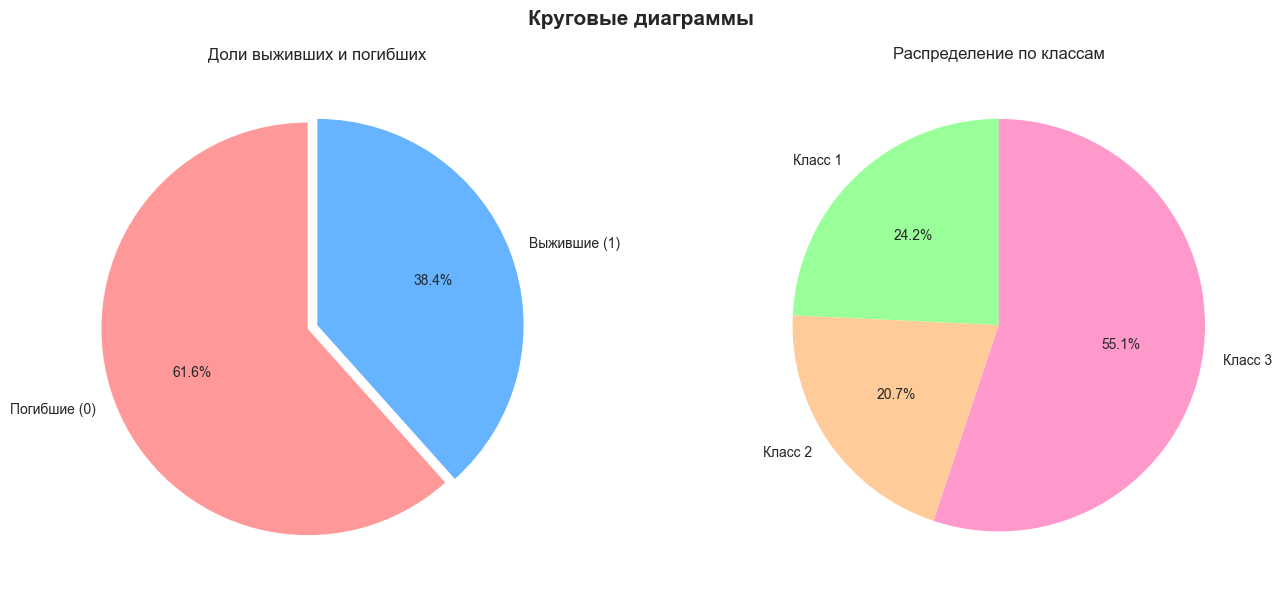

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Круговые диаграммы', fontsize=15, fontweight='bold')

# Pie chart для Survived
survived_vals = data['Survived'].value_counts().sort_index()
axes[0].pie(
    survived_vals,
    labels=['Погибшие (0)', 'Выжившие (1)'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff9999', '#66b3ff'],
    explode=(0.05, 0)
)
axes[0].set_title('Доли выживших и погибших')

# Pie chart для Pclass
pclass_vals = data['Pclass'].value_counts().sort_index()
axes[1].pie(
    pclass_vals,
    labels=[f'Класс {i}' for i in pclass_vals.index],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#99ff99', '#ffcc99', '#ff99cc']
)
axes[1].set_title('Распределение по классам')

plt.tight_layout()
plt.show()

**Интерпретация круговых диаграмм:**

1. **Survived**: Только 38.4% выжили, 61.6% погибли.
2. **Pclass**: Третий класс составил 55.1%, второй — 20.7%, первый — 24.2% пассажиров.

## 5. Pairplot числовых признаков

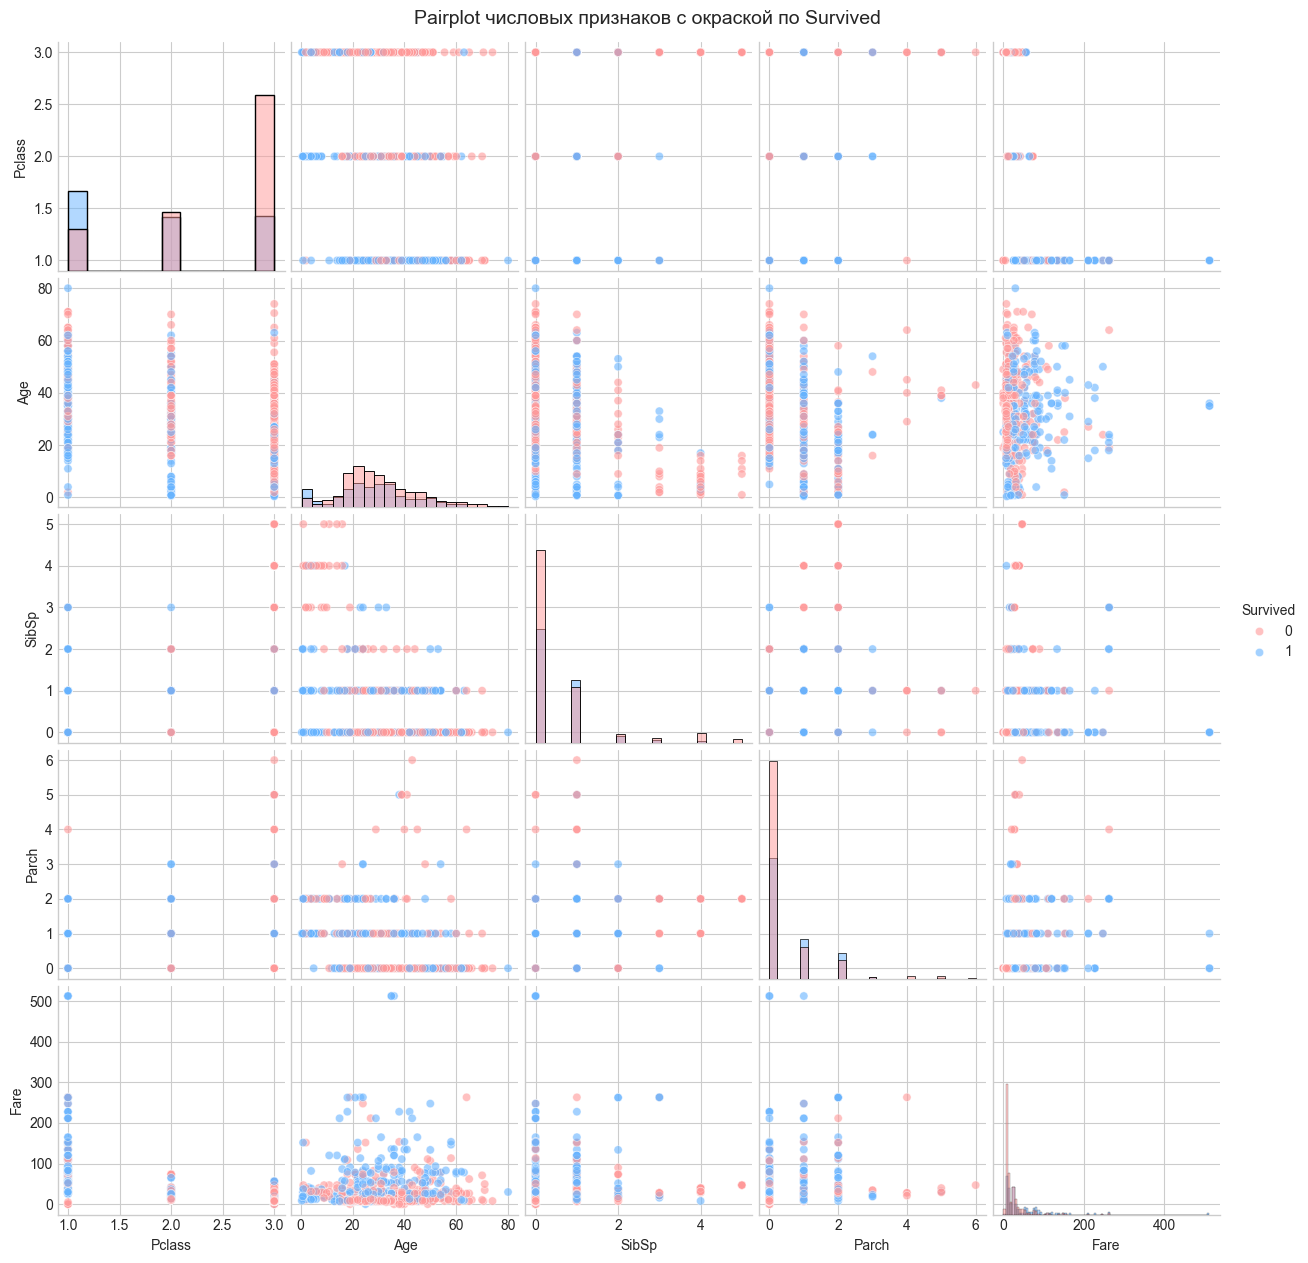

In [ ]:
# Выбор числовых столбцов
cols_numeric = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
data_clean = data[cols_numeric].dropna()

# Pairplot с окраской по выживаемости
g = sns.pairplot(
    data_clean,
    hue='Survived',
    diag_kind='hist',
    palette={0: '#ff9999', 1: '#66b3ff'},
    plot_kws={'alpha': 0.6}
)
g.fig.suptitle('Pairplot числовых признаков с окраской по Survived', y=1.01, fontsize=14)
plt.show()

**Интерпретация pairplot:**

- **Pclass vs Survived**: Пассажиры 1-го класса имели значительно более высокую выживаемость.
- **Fare vs Survived**: Выжившие чаще имели более высокую стоимость билета.
- **Age**: Наблюдается тенденция более высокой выживаемости детей.
- **SibSp/Parch**: Большинство путешествовали одни, связь с выживаемостью слабая.

## 6. Violin plot возраста по полу

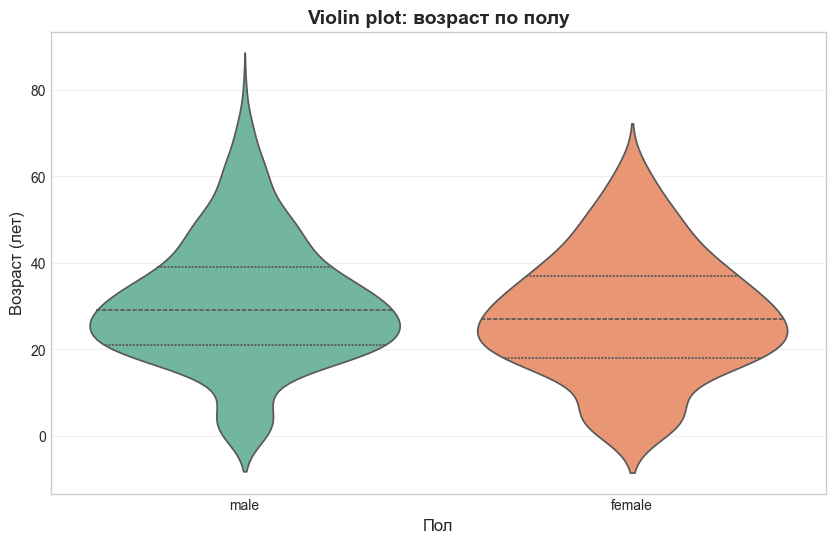

In [6]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=data, x='Sex', y='Age', palette='Set2', inner='quartile')
plt.title('Violin plot: возраст по полу', fontsize=14, fontweight='bold')
plt.xlabel('Пол', fontsize=12)
plt.ylabel('Возраст (лет)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

**Интерпретация violin plot:**

- **Медиана**: У мужчин и женщин медианный возраст примерно одинаковый (~28-30 лет).
- **Форма распределения**: Оба пола имеют схожее распределение с пиком в районе 20-30 лет.
- **Диапазон**: От младенцев (~0 лет) до пожилых (~80 лет).
- У женщин чуть более выражена концентрация в возрасте 20-40 лет.

## 7. Heatmap корреляционной матрицы

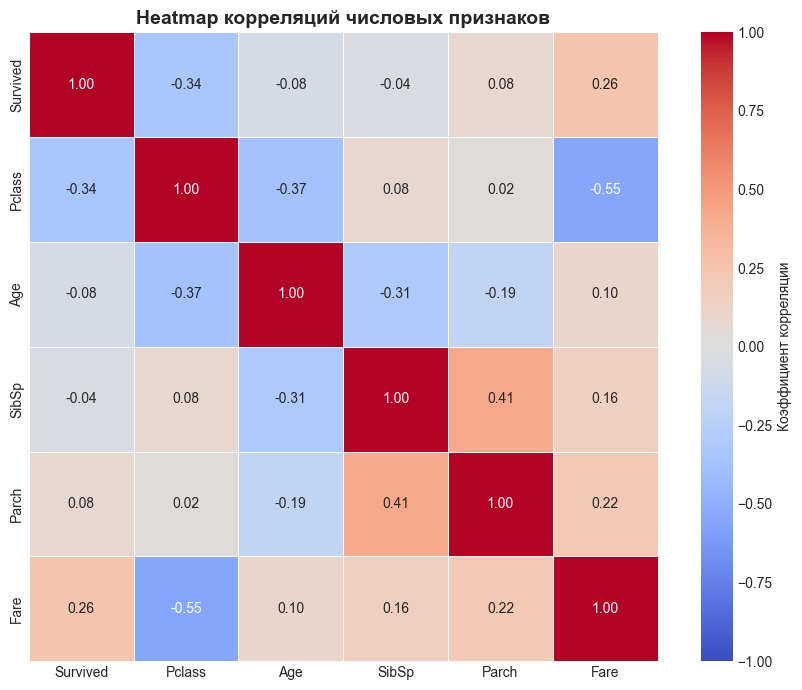

In [7]:
# Корреляционная матрица
corr_data = data[cols_numeric].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_data,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Коэффициент корреляции'}
)
plt.title('Heatmap корреляций числовых признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Интерпретация heatmap:**

**Сильные корреляции:**
- **Fare ↔ Pclass (-0.55)**: Чем выше класс (меньшее число), тем выше стоимость.
- **Survived ↔ Fare (0.26)**: Дорогие билеты → выше шансы на выживание.
- **Survived ↔ Pclass (-0.34)**: 1-й класс выживал чаще.

**Умеренные корреляции:**
- **SibSp ↔ Parch (0.41)**: Семьи часто имели и супругов, и детей.

**Слабые корреляции:**
- **Age** практически не коррелирует с другими признаками.

## 8. Sunburst plot (Plotly)

In [8]:
# Подготовка данных
data_sb = data.copy()
data_sb['Pclass_str'] = data_sb['Pclass'].apply(lambda x: f'Класс {x}')
data_sb['Sex_rus'] = data_sb['Sex'].map({'male': 'Мужчины', 'female': 'Женщины'})

# Создание sunburst
fig = px.sunburst(
    data_sb,
    path=['Pclass_str', 'Sex_rus'],
    title='Sunburst: распределение пассажиров по классу и полу',
    color='Sex_rus',
    color_discrete_map={'Мужчины': '#66b3ff', 'Женщины': '#ff9999'},
    width=700,
    height=600
)
fig.update_traces(textinfo='label+percent parent')
fig.show()

**Интерпретация sunburst:**

- **Внешний круг**: Доминирование 3-го класса (~55% пассажиров).
- **Внутренний круг**: 
  - В 1-м классе соотношение ~60% мужчин, ~40% женщин.
  - Во 2-м классе ~65% мужчин.
  - В 3-м классе ~70% мужчин, ~30% женщин.
- График наглядно показывает преобладание мужчин во всех классах.